In [1]:
import os
import re
import pickle
from wordcloud import WordCloud
import numpy as np
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import FuncFormatter

In [2]:
# read in atlases
# atlas_base_path = "/home/zachkaras/fmri/fmri_model/analysis/pipeline/atlases"
atlas_base_path = "/home/zachkaras/fmri_model/analysis/pipeline/atlases"

# read in 2d mni mask
mask = nib.load(f"{atlas_base_path}/MNI152_T1_2mm_brain_mask.nii.gz")
og_shape = mask.shape
mask = mask.get_fdata().flatten()
brain_idx = np.where(mask>0)[0]

atlas = nib.load(f"{atlas_base_path}/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz")
atlas_vec = atlas.get_fdata().flatten()
atlas_only_brain = atlas_vec[brain_idx] # contains the schaefer parcel numbers
cortex_vx = np.where(atlas_only_brain != 0)[0]
parcel_nums = atlas_only_brain[cortex_vx]

# Making empty templates to save output
empty_schaefer = np.zeros(atlas_only_brain.shape)
empty_mni = np.zeros(atlas_vec.shape)


In [3]:
class Regression_Info(object):
    # [model_name, task, look_ahead, n_delays, layer, stat]
    def __init__(self, model_name=None, task=None, look_ahead=None, n_delays=None, layer=None, stat=None):
        self.model_name = model_name
        self.task       = task
        self.look_ahead = look_ahead
        self.n_delays   = n_delays
        self.layer      = layer
        self.stat       = stat
        
    def __str__(self):
        return f"{self.model_name}, {self.task}, {self.look_ahead}, {self.n_delays}, {self.layer}, {self.stat}"

def nested_dict():
        return defaultdict(nested_dict)

def convert_to_nifti(values):
    # working backwards to save correlation values as voxels in MNI space
    empty_schaefer[cortex_vx] = values
    empty_mni[brain_idx] = empty_schaefer
    result_brain = np.reshape(empty_mni, og_shape)

    # Saving results
    nifti_result = nib.Nifti1Image(result_brain, affine=atlas.affine, header=atlas.header)
    nib.save(nifti_result, "test_plotting.nii.gz")
    return result_brain, nifti_result


def parse_regression_info(path):
    
    parts = path.split('-') 
    # example: ['codegemma_7b', 'code', 'look_ahead_by_1', 'ndelays_0', 'layer_28', 'correlations.pkl']
    info = Regression_Info()
    info.model_name = parts[0]
    info.task       = parts[1]
    info.look_ahead = parts[2]
    info.n_delays   = parts[3]
    info.layer      = parts[4]
    info.stat       = (parts[5])[:-4]
    
    return info


def find_cutoff(vec, threshold = 10**4):
    
    # I can find the threshold point based on sorting, then keep everything in the same place
    copy = vec.copy()
    copy.sort()
    cutoff = copy[-threshold-1]
    return cutoff


def iterate_through_participants(filepath, stat):
    participants = os.listdir(filepath)
    
    stat_collection = nested_dict()
    parcel_collection = nested_dict()
    
    # iterating through participants
    for p in participants:
        print(p)
        datapath = f"{filepath}/{p}"
        files = os.listdir(datapath)
        stat_files = [f for f in files if re.search(stat, f)]
        
        # iterating through the stat files
        # these are vectors of correlation coefficients between predicted and recorded signal
        # Different parameters were adjusted, so the folder contains all the possibilities
        # [model_name, task, look_ahead, n_delays, layer, stat]
        for sf in stat_files:
            
            info = parse_regression_info(sf)
            
            stat_file = f"{datapath}/{sf}"
            with open(stat_file, 'rb') as f:
                try:
                    stat_vec = pickle.load(f)
                except:
                    print(f"issue with {p}: {sf}")
                
            # filter to top 10k, 10k is default parameter but can be changed with threshold argument
            cutoff = find_cutoff(stat_vec)
            # print(len(stat_vec))
            top_voxel_idx = (np.where(stat_vec > cutoff))[0]
            top_voxel_vals = stat_vec[top_voxel_idx]
            top_parcels = parcel_nums[top_voxel_idx]
            top_parcels = [int(parcel) for parcel in top_parcels]
            
            # print(len(top_voxel_vals), top_voxel_vals)
            # plt.hist(top_parcels, bins=400)
            # plt.title("Schaefer Parcel Numbers for top 10K voxels")
            # top_parcels = [f"p{str(p)[:-2]}" for p in top_parcels]
            # parcel_string = " ".join(top_parcels)
            # print(parcel_string)
            # print(top_parcels)
            # wc = WordCloud(width=800,height=400, background_color="white").generate(parcel_string)
            # plt.figure()
            # plt.imshow(wc)
            # plt.show()
            # save into big dictionary structure
            # 6 figures, one for each model
            # in 2 rows, one for each task
            
            # Should I keep one thing consistent, like only look at the best layer for a given model
            # and only the best performing participants?
            # It should depend on the research questions...
            # No I'd like to see across a range of participants
            # I feel like layer 
            parcel_collection[p][info.task][info.model_name][info.n_delays][info.look_ahead][info.layer] = top_parcels
            
            if info.look_ahead not in stat_collection[info.task][info.model_name][info.n_delays].keys():
                stat_collection[info.task][info.model_name][info.n_delays][info.look_ahead]  = top_voxel_vals
            else:
                np.append(stat_collection[info.task][info.model_name][info.n_delays][info.look_ahead], top_voxel_vals)
                # np.append(parcel_collection[p][info.task][info.model_name][info.n_delays][info.look_ahead][info.layer], top_parcels)
            # print(stat_vec)
            # break
        # break
    
    return stat_collection, parcel_collection
        
        

In [4]:
# iterate through directories, parse the file names, and accumulate stats

# parsing file names [model_name, task, look_ahead, n_delays, layer, stat]
# filepath = "/storage1/fmri_model_data/ridge_regression_pca_params"
filepath = "/data/zachkaras/fmri_model_data/ridge_regression_pca_params"
stat_collection, parcel_collection = iterate_through_participants(filepath, 'correlations')



111
117
203
204
129
134
144
133
109
142
150
112
122
141
101
125
108
105
119
121
118
138
151
130
201


ndelays_0 look_ahead_by_0
ndelays_0 look_ahead_by_1
ndelays_0 look_ahead_by_3
ndelays_0 look_ahead_by_5
ndelays_0 look_ahead_by_10
ndelays_4 look_ahead_by_0
ndelays_4 look_ahead_by_1
ndelays_4 look_ahead_by_3
ndelays_4 look_ahead_by_5
ndelays_4 look_ahead_by_10
ndelays_10 look_ahead_by_0
ndelays_10 look_ahead_by_1
ndelays_10 look_ahead_by_3
ndelays_10 look_ahead_by_5
ndelays_10 look_ahead_by_10
ndelays_16 look_ahead_by_0
ndelays_16 look_ahead_by_1
ndelays_16 look_ahead_by_3
ndelays_16 look_ahead_by_5
ndelays_16 look_ahead_by_10
ndelays_20 look_ahead_by_0
ndelays_20 look_ahead_by_1
ndelays_20 look_ahead_by_3
ndelays_20 look_ahead_by_5
ndelays_20 look_ahead_by_10
ndelays_0 look_ahead_by_0
ndelays_0 look_ahead_by_1
ndelays_0 look_ahead_by_3
ndelays_0 look_ahead_by_5
ndelays_0 look_ahead_by_10
ndelays_4 look_ahead_by_0
ndelays_4 look_ahead_by_1
ndelays_4 look_ahead_by_3
ndelays_4 look_ahead_by_5
ndelays_4 look_ahead_by_10
ndelays_10 look_ahead_by_0
ndelays_10 look_ahead_by_1
ndelays_10 loo

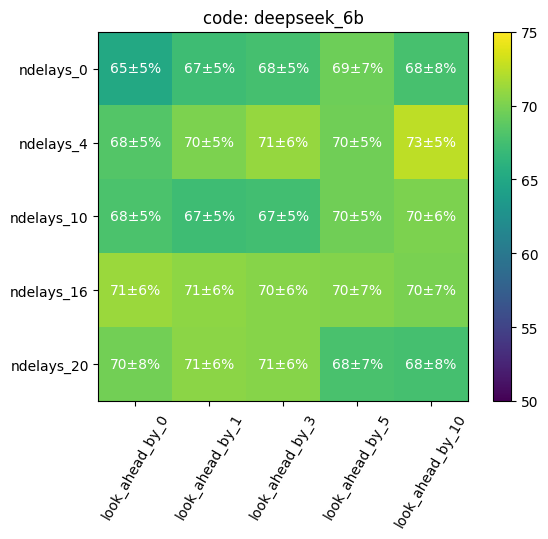

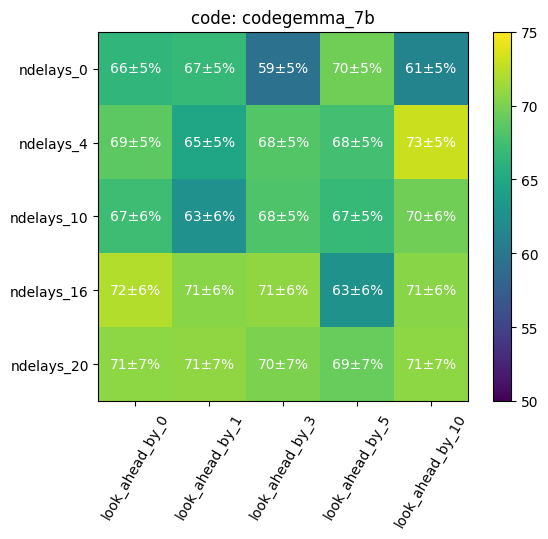

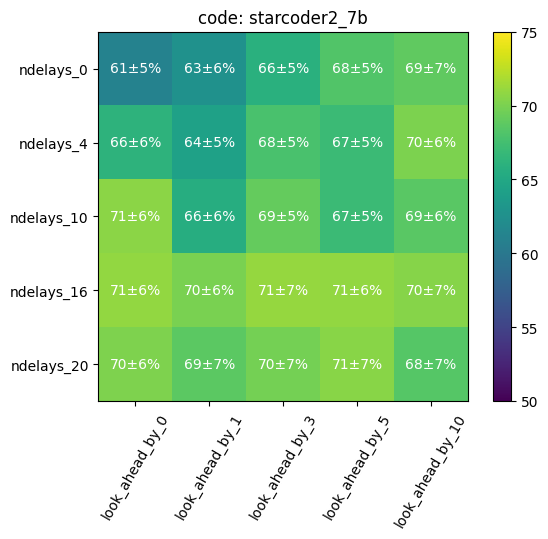

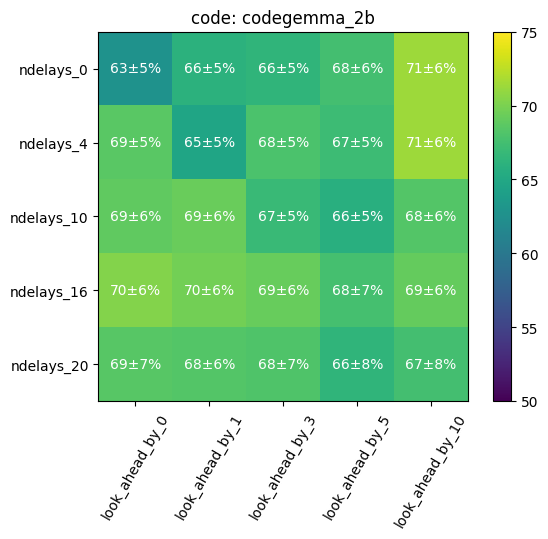

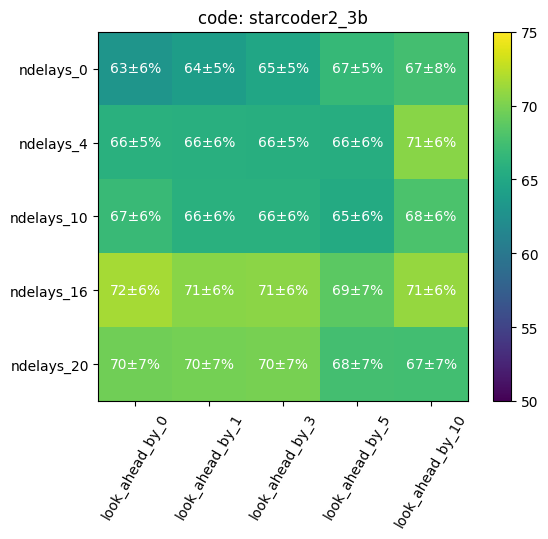

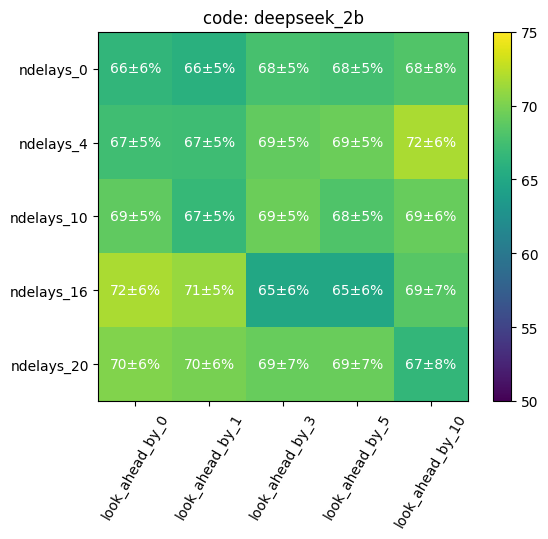

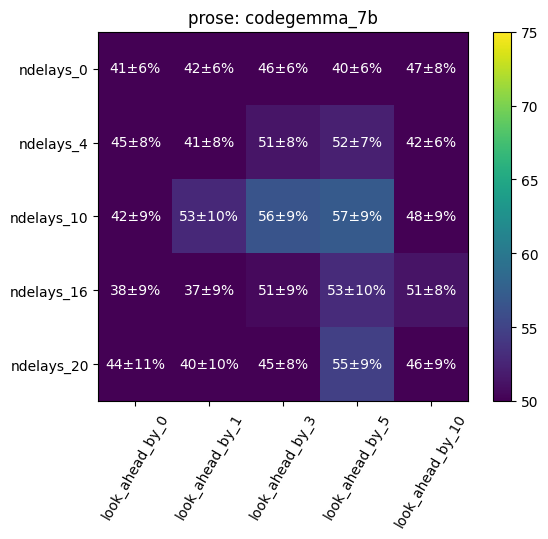

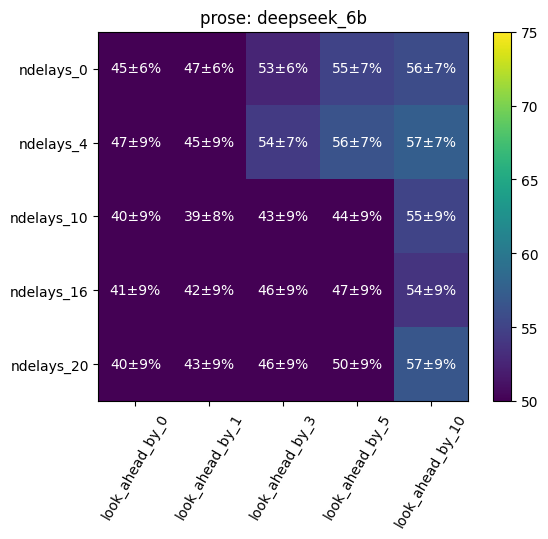

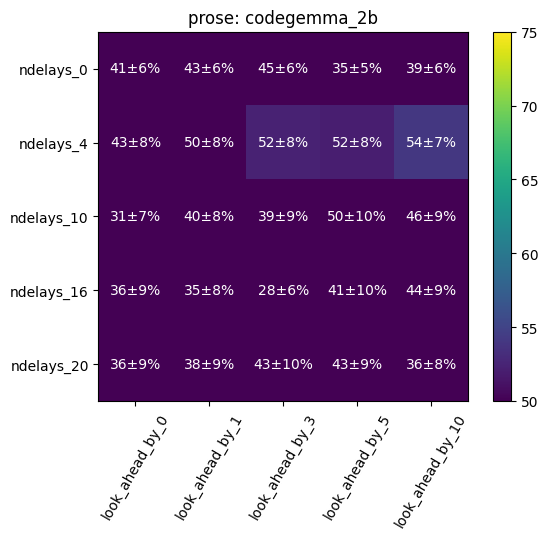

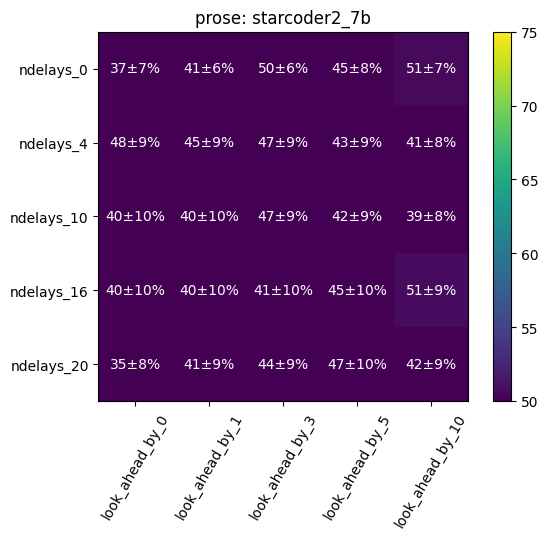

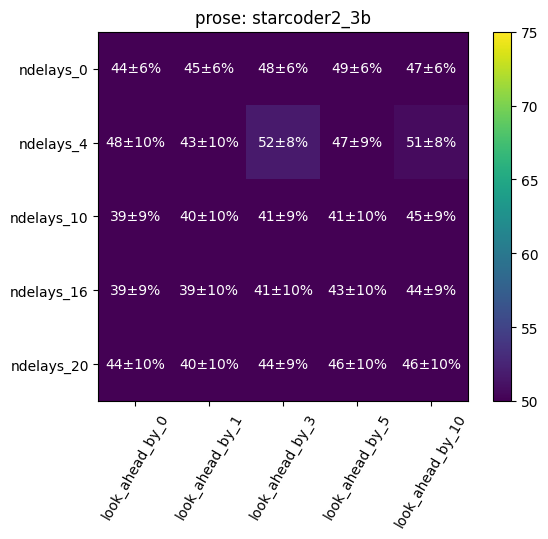

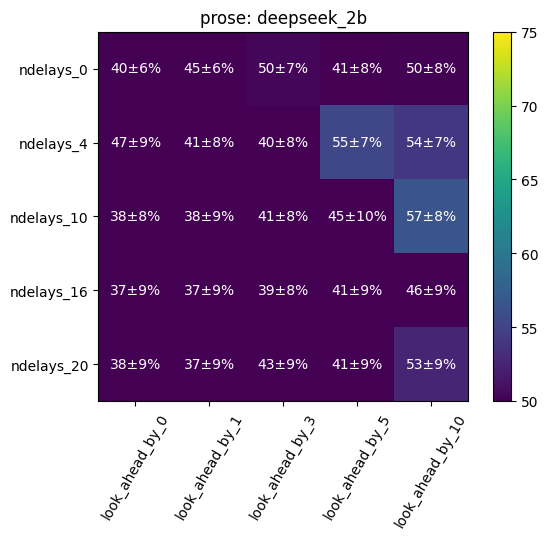

In [ ]:
# EXAMPLE: stat_collection[info.task][info.model_name][info.n_delays][info.look_ahead]
# need to iterate through dictionary structure

# param_ave = nested_dict()

for task, model_delay_peek_vals in stat_collection.items():
    for model, delay_peek_vals in model_delay_peek_vals.items():
        param_delays = []
        delay_stds = []
        delay_nums = [0,4,10,16,20]
        delay_labels = [f"ndelays_{d}" for d in delay_nums]
        for dl in delay_labels:
            # print(dl)
            peek_vals = delay_peek_vals[dl]
            peek_nums = [0,1,3,5,10]
            peek_labels = [f'look_ahead_by_{p}' for p in peek_nums]
            
            param_averages = []
            param_stds = []
            for pl in peek_labels:
                print(dl, pl)
                vals = peek_vals[pl]
                std = np.std(vals)
                ave = np.mean(vals)
                param_averages.append(ave)
                param_stds.append(std)
            param_delays.append(param_averages)
            delay_stds.append(param_stds)

        fig, ax = plt.subplots()
        
        im = ax.imshow(param_delays, vmin=0.5, vmax=0.75)
        ax.set_xticks(ticks=range(0,5), labels=peek_labels, rotation=60)
        ax.set_yticks(ticks=range(0,5), labels=delay_labels)
        
        for i in range(len(delay_labels)):
            for j in range(len(peek_labels)):
                text = ax.text(j, i, f"{(param_delays[i][j])*100:.0f}\u00B1{(delay_stds[i][j])*100:.0f}%",
                       ha="center", va="center", color="w")
        
        cbar = fig.colorbar(im, ax=ax)
        cbar.ax.yaxis.set_major_formatter(
            FuncFormatter(lambda x, pos: f"{x*100:.0f}")
        )
        title = f"{task}: {model}"
        ax.set_title(title)
        plt.savefig(f"results/UPDATED_022026-{task}-{model}-heatmap.png", dpi=150)
        
    #     break
    # break

        

In [ ]:
# plot
for task, model_delay_peek_vals in param_ave.items():
    for model, delay_peek_vals in model_delay_peek_vals.items():
        for delay, peek_vals in delay_peek_vals.items():
            for peek, vals in peek_vals.items():
                delays = delay_peek_vals.keys()
                peeks = peek_vals.keys()
                print(delays, peeks)
                print(peek_vals.values())
            break
        break
    break
    

dict_keys(['ndelays_0', 'ndelays_16', 'ndelays_10', 'ndelays_4', 'ndelays_20']) dict_keys(['look_ahead_by_1', 'look_ahead_by_0', 'look_ahead_by_10', 'look_ahead_by_3', 'look_ahead_by_5'])
dict_values([0.625021287886603, 0.6611207984245097, 0.6831812698758524, 0.686187353263972, 0.6737777035535836])


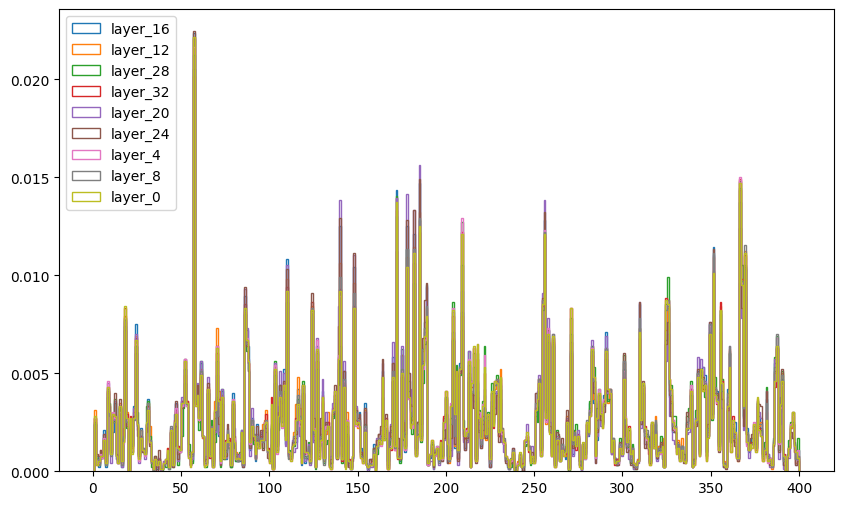

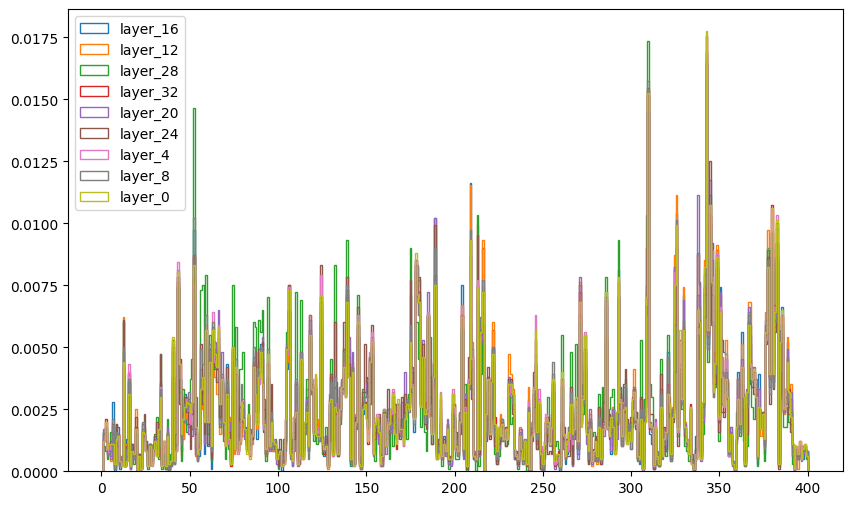

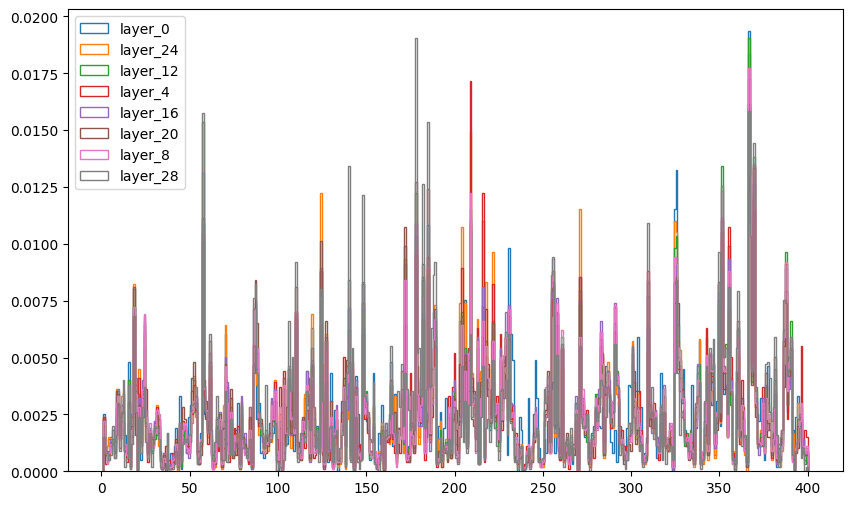

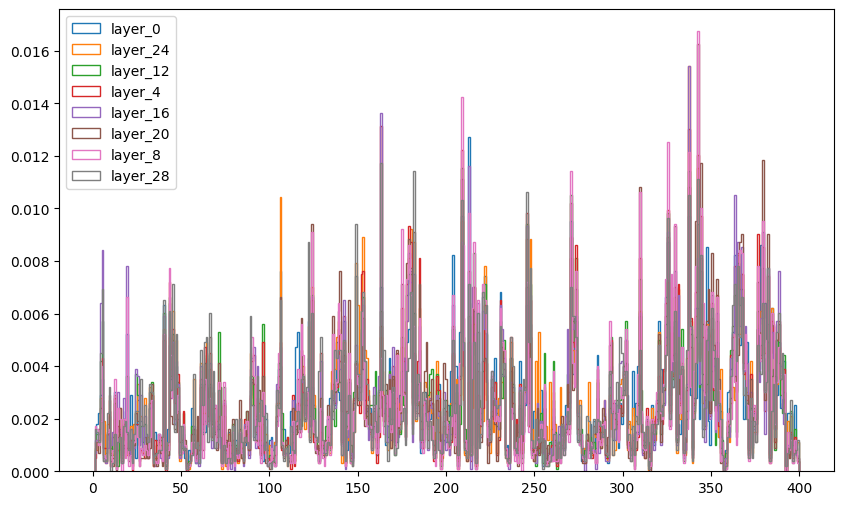

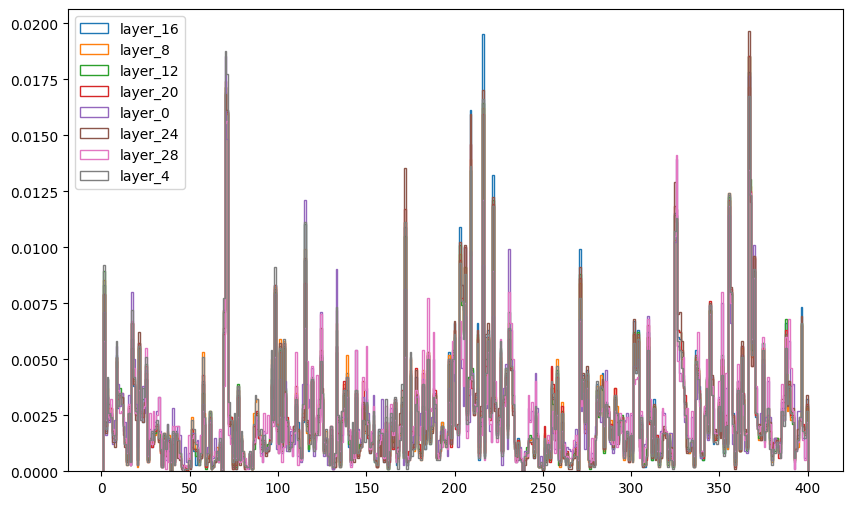

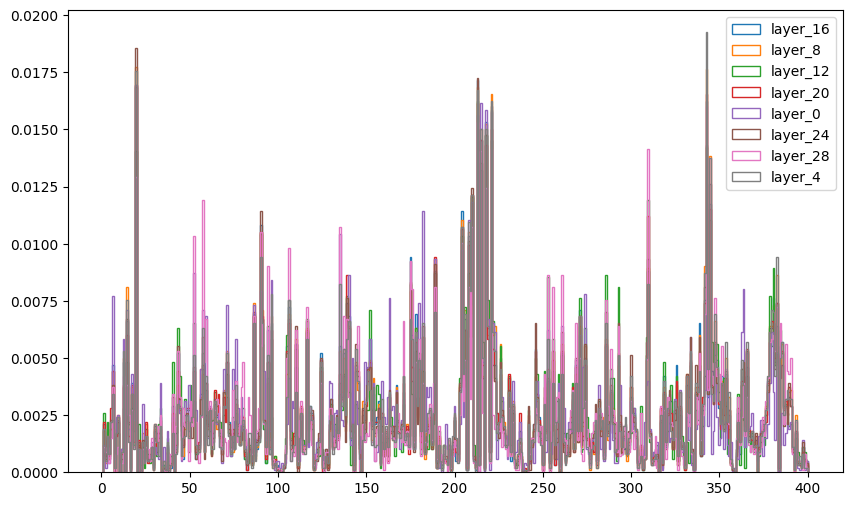

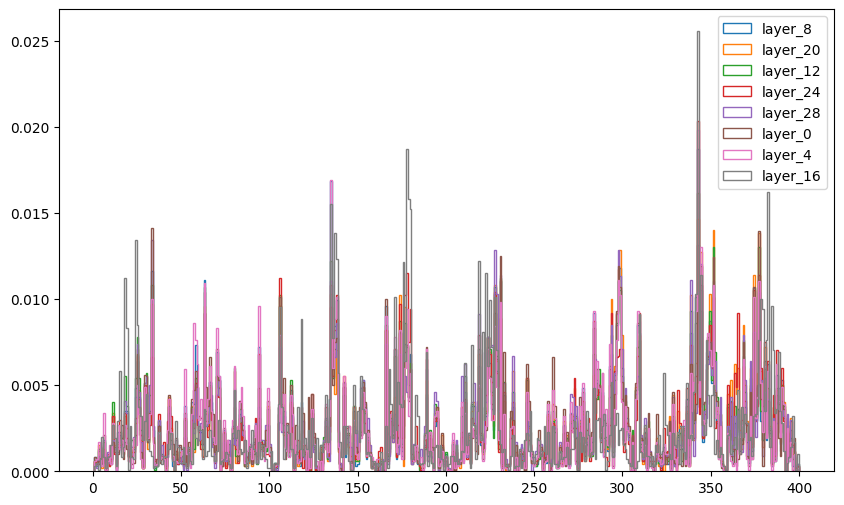

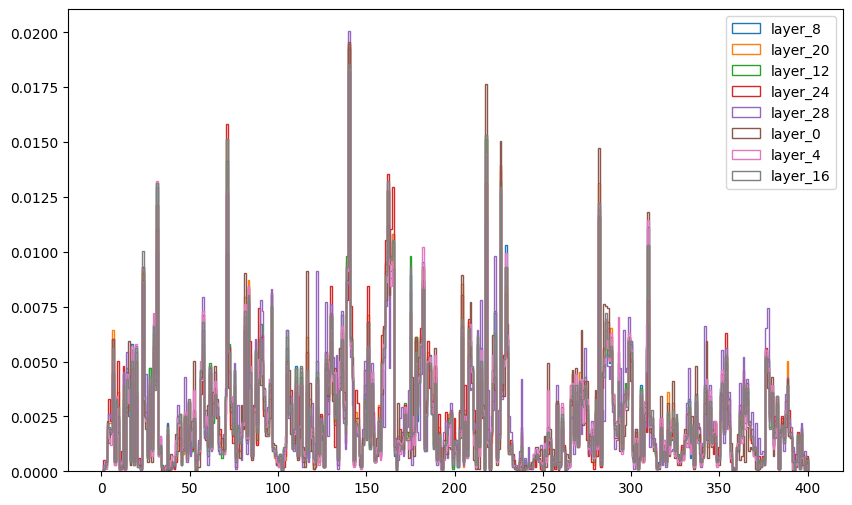

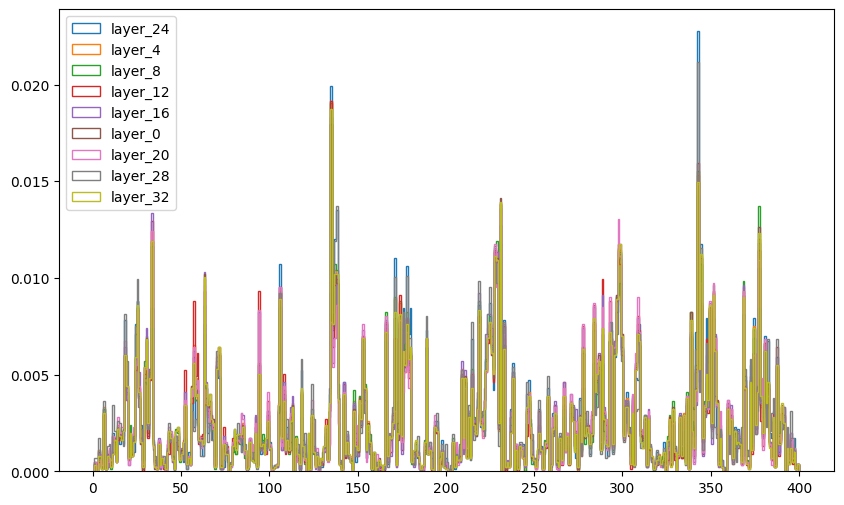

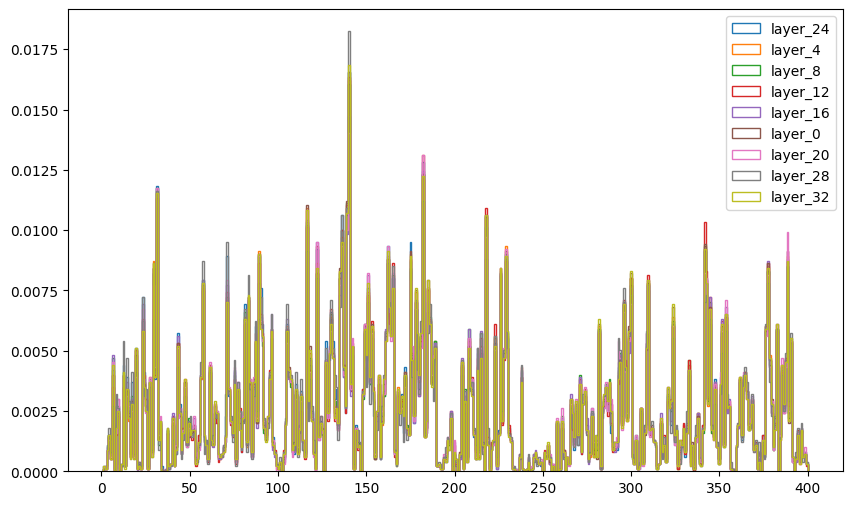

In [7]:
# iterate through parcel_collection
# participant, task, model name, delays, look ahead, layer

# For a given participant, iterate through 

# I'd like to plot all 8 layers for a given participant for a given model, for a given look ahead, for a given delay
best_models = ['code-deepseek_6b-ndelays_4-look_ahead_by_10', 
               'code-codegemma_7b-ndelays_4-look_ahead_by_10',
               'code-codegemma_7b-ndelays_16-look_ahead_by_0', 
               'prose-codegemma_7b-ndelays_10-look_ahead_by_5', 
               'prose-deepseek_6b-ndelays_20-look_ahead_by_10']

# Maybe a really good participant and a mediocre participant
# Good - 121
# Med. - 150
key_participants = ['121', '150']
for m in best_models:
    # print(m)
    parts = m.split('-')
    task,model,delays,look_ahead = parts[0],parts[1],parts[2],parts[3]

    for vip in key_participants:
        # print(vip, task, model, delays, look_ahead)
        # print(parcel_collection[vip][task][model][delays][look_ahead]['layer_0'])
        top_parcels = parcel_collection[vip][task][model][delays][look_ahead]
        
        # wrap this for loop in a plot to collect the different histograms
        plt.figure(figsize=(10,6))
        bins = 400

        for layer,vals in top_parcels.items():
            # 
            # plt.hist(vals, bins=bins, alpha=0.35, density=False)
            plt.hist(vals, bins=bins, histtype='step', density=True)
        plt.legend(list(top_parcels.keys()))
        plt.show()
    # break
            
    


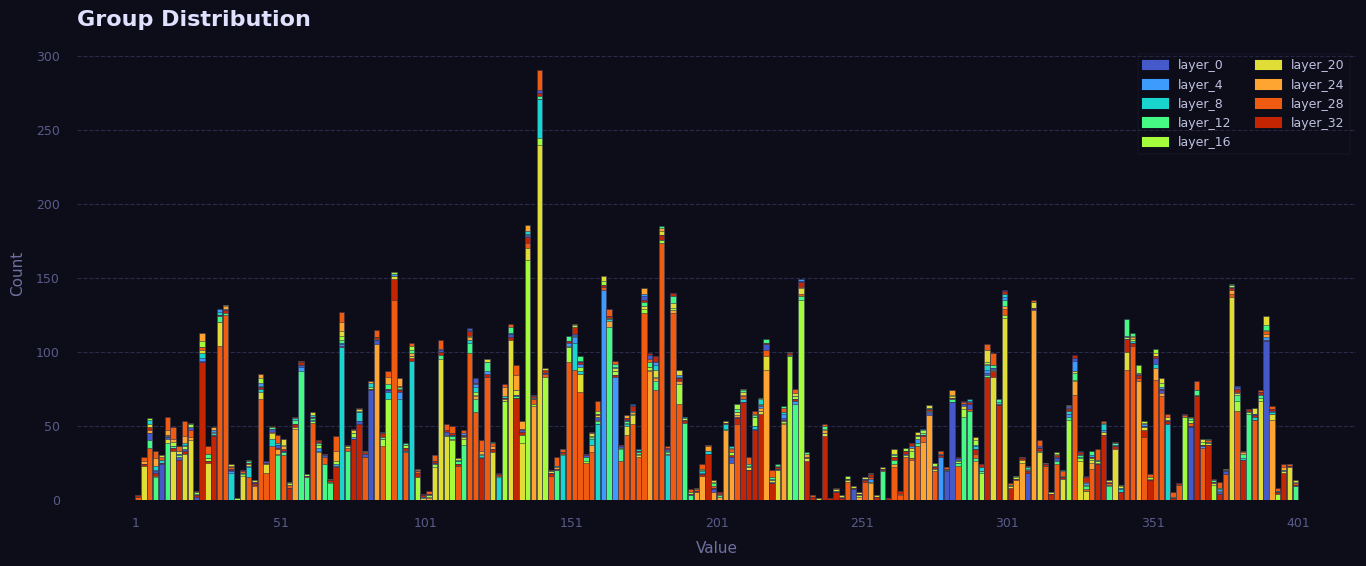

Saved → histogram_output.png


In [23]:
"""
Overlapping Histogram — largest bar drawn first (behind), smaller bars in front.
For each bin, each layer draws from 0 to its own count (no stacking).
Accepts data as: {'label_1': [...], 'label_2': [...], ...}
Values should be integers in range 1–400.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Configuration ────────────────────────────────────────────────────────────

NUM_BINS = 200          # number of histogram bins
VALUE_MIN = 1          # minimum possible value in data
VALUE_MAX = 400        # maximum possible value in data
FIGSIZE = (14, 6)      # figure dimensions (width, height)
CHART_TITLE = "Group Distribution"

# ─────────────────────────────────────────────────────────────────────────────


def build_histogram(data: dict, num_bins: int, vmin: int, vmax: int) -> tuple:
    """
    Returns:
        bin_edges  : array of length num_bins + 1
        counts     : dict {label: array of length num_bins}
    """
    bin_edges = np.linspace(vmin, vmax + 1, num_bins + 1)
    counts = {}
    for label, values in data.items():
        hist, _ = np.histogram(values, bins=bin_edges)
        counts[label] = hist
    return bin_edges, counts


def plot_histogram(data: dict, num_bins: int = NUM_BINS,
                   vmin: int = VALUE_MIN, vmax: int = VALUE_MAX,
                   title: str = CHART_TITLE, figsize: tuple = FIGSIZE):

    bin_edges, counts = build_histogram(data, num_bins, vmin, vmax)
    labels = list(counts.keys())
    n_bins = num_bins
    bin_width = bin_edges[1] - bin_edges[0]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Seaborn / matplotlib theme
    sns.set_theme(style="darkgrid", context="talk")
    palette = sns.color_palette("turbo", len(labels))

    # Map labels to palette in sorted layer order so early layers → cool, late → warm
    sorted_labels = sorted(labels, key=lambda lbl: int(lbl.split("_")[-1]))
    label_color = {lbl: palette[i] for i, lbl in enumerate(sorted_labels)}

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("#0d0d1a")
    ax.set_facecolor("#0d0d1a")
    ax.grid(axis="y", color="#2a2a4a", linewidth=0.8, linestyle="--", zorder=0)
    ax.grid(axis="x", visible=False)

    # ── Per-bin overlapping bars ──────────────────────────────────────────────
    # Draw largest bar first (behind), smallest last (in front).
    # Each bar goes from 0 to its own count — no stacking.

    for b in range(n_bins):
        # Largest count drawn first so smaller bars are visible on top
        sorted_by_count = sorted(labels, key=lambda lbl: counts[lbl][b], reverse=True)

        for lbl in sorted_by_count:
            val = counts[lbl][b]
            if val == 0:
                continue
            ax.bar(
                bin_centers[b],
                val,
                width=bin_width * 0.92,
                bottom=0,
                color=label_color[lbl],
                # alpha=0.6,
                edgecolor="#2d2d4c",
                linewidth=0.4,
                zorder=2,
            )

    # ── Axes styling ──────────────────────────────────────────────────────────
    ax.set_title(title, color="#e0e0ff", fontsize=16, fontweight="bold",
                 pad=16, loc="left")
    ax.set_xlabel("Value", color="#7070a0", fontsize=11, labelpad=8)
    ax.set_ylabel("Count", color="#7070a0", fontsize=11, labelpad=8)
    ax.tick_params(colors="#5a5a8a", labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # X-ticks at bin edges (show ~8 labels to avoid crowding)
    tick_step = max(1, n_bins // 8)
    tick_positions = bin_edges[::tick_step]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{int(v)}" for v in tick_positions], color="#5a5a8a")

    # ── Legend (in sorted layer order) ───────────────────────────────────────
    legend_patches = [
        mpatches.Patch(color=label_color[lbl], label=lbl)
        for lbl in sorted_labels
    ]
    ax.legend(
        handles=legend_patches,
        loc="upper right",
        frameon=True,
        framealpha=0.15,
        edgecolor="#2a2a4a",
        facecolor="#0d0d1a",
        labelcolor="#c0c0e0",
        fontsize=9,
        ncol=2,
    )

    plt.tight_layout()
    plt.savefig("histogram_output.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("Saved → histogram_output.png")


if __name__ == "__main__":
    plot_histogram(top_parcels)


In [32]:
# maybe violin plots or word clouds to show predominant schaefer parcels
from nilearn import datasets
ho = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
nii = nib.load(ho['filename'])

[fetch_atlas_harvard_oxford] Dataset found in /home/zachkaras/nilearn_data/fsl

In [35]:
# TODO - line up schaefer atlas and 

'/home/zachkaras/nilearn_data/fsl/data/atlases/HarvardOxford/HarvardOxford-cort-maxprob-thr25-2mm.nii.gz'

FileNotFoundError: [Errno 2] No such file or directory: 'lh.aparc.annot'